# Week 2 Deliverable

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
list = pd.read_csv("list_residentials.csv")
sold = pd.read_csv("sold_residentials.csv")

/var/folders/y8/n1dk_n9n2fsf3cpk4z474lmc0000gn/T/ipykernel_34490/2375086182.py:1: DtypeWarning: Columns (2,43) have mixed types. Specify dtype option on import or set low_memory=False.
  list = pd.read_csv("list_residentials.csv")
/var/folders/y8/n1dk_n9n2fsf3cpk4z474lmc0000gn/T/ipykernel_34490/2375086182.py:2: DtypeWarning: Columns (0,1,9,64,78,79,80) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv("sold_residentials.csv")


## Sold Dataset

### Dataset Understanding

In [5]:
#first five rows of sold dataset
sold.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,1.0,Other,94401,6472.0,NaN,NaN,CRMLS,CRMLS_MLSL,NaN,NaN
1,SanDiego,SanDiego,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,...,2.0,NaN,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,...,2.0,NaN,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1079166779,davidmartz@compass.com,...,2.0,Palm Springs Unified,92262,NaN,13504.0,NaN,CRMLS,CRMLS_MLSL,NaN,NaN
4,Southland,Southland,NaN,False,NaN,NaN,False,1890500.0,1075037759,karen.klein@theagencyre.com,...,2.0,Los Angeles Unified,91356,0.0,17873.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN


In [6]:
#591,465 rows and 84 columns for sold
sold.shape

(423856, 82)

In [7]:
#all the column names in sold
sold.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

In [8]:
#datatypes for all the columns in sold
sold.dtypes

BuyerAgentAOR                    object
ListAgentAOR                     object
Flooring                         object
ViewYN                           object
WaterfrontYN                     object
                                 ...   
MiddleOrJuniorSchoolDistrict    float64
OriginatingSystemName            object
OriginatingSystemSubName         object
BuyerAgencyCompensationType      object
BuyerAgencyCompensation         float64
Length: 82, dtype: object

In [9]:
#Identify property types in sold
sold["PropertyType"].value_counts()

PropertyType
Residential    423856
Name: count, dtype: int64

In [10]:
#Checking property type categories in sold
sold["PropertyType"].unique()

array(['Residential'], dtype=object)

In [11]:
#filter to just residential property types and identify the shape of the new sold dataset
sold_new = sold[sold["PropertyType"]=="Residential"]
sold_new.shape

(423856, 82)

### Missing Value Analysis

In [12]:
#identify percentage of missing data in the columns of list
sold_missing_percent = sold_new.isnull().mean()*100
sold_missing_percent

BuyerAgentAOR                    12.415301
ListAgentAOR                     10.899928
Flooring                         35.994772
ViewYN                            8.542524
WaterfrontYN                     99.936771
                                   ...    
MiddleOrJuniorSchoolDistrict    100.000000
OriginatingSystemName            82.986911
OriginatingSystemSubName         82.986911
BuyerAgencyCompensationType      89.115171
BuyerAgencyCompensation          89.117766
Length: 82, dtype: float64

In [13]:
#identify columns in sold that have over 90% missing data
sold_missing_percent[sold_missing_percent>90].index

Index(['WaterfrontYN', 'BasementYN', 'FireplacesTotal',
       'AboveGradeFinishedArea', 'TaxAnnualAmount', 'BuilderName', 'TaxYear',
       'BuildingAreaTotal', 'ElementarySchoolDistrict',
       'CoBuyerAgentFirstName', 'BelowGradeFinishedArea', 'BusinessType',
       'CoveredSpaces', 'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict'],
      dtype='object')

In [14]:
#drop irrelevant columns in sold that have over 90% missing data
drop_sold_cols = ['FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount',
       'BuilderName', 'TaxYear', 'BuildingAreaTotal',
       'ElementarySchoolDistrict', 'CoBuyerAgentFirstName',
       'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces',
       'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict']
final_sold = sold_new.drop(columns=drop_sold_cols)
final_sold.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,False,1.0,Other,94401,6472.0,NaN,CRMLS,CRMLS_MLSL,NaN,NaN
1,SanDiego,SanDiego,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,...,False,2.0,NaN,91950,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,...,False,2.0,NaN,91950,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1079166779,davidmartz@compass.com,...,False,2.0,Palm Springs Unified,92262,NaN,13504.0,CRMLS,CRMLS_MLSL,NaN,NaN
4,Southland,Southland,NaN,False,NaN,NaN,False,1890500.0,1075037759,karen.klein@theagencyre.com,...,False,2.0,Los Angeles Unified,91356,0.0,17873.0,CRMLS,CRMLS_CRM,NaN,NaN


### Numeric Distribution Review

In [15]:
#Percentile summaries for the following columns in sold
numeric_cols_sold = ["ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea", "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket", "YearBuilt"]
final_sold[numeric_cols_sold].describe(percentiles=[0.10,0.25,0.50,0.75,0.90])

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,4.238540e+05,4.238560e+05,4.230670e+05,4.236210e+05,3.907730e+05,423844.000000,423789.000000,423856.000000,423480.000000
mean,1.187414e+06,1.138482e+06,1.222107e+06,1.903579e+03,6.494411e+01,3.202265,2.536248,37.730361,1978.626729
std,6.095594e+06,1.357570e+06,6.644509e+06,2.616793e+04,1.580772e+04,1.067672,1.133602,50.543013,26.299505
min,0.000000e+00,5.250000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-288.000000,1776.000000
10%,4.150000e+05,4.180000e+05,4.250000e+05,9.830000e+02,6.200000e-02,2.000000,1.000000,4.000000,1947.000000
25%,5.750000e+05,5.750000e+05,5.850000e+05,1.248000e+03,1.200000e-01,3.000000,2.000000,8.000000,1960.000000
50%,8.200000e+05,8.100000e+05,8.250000e+05,1.643000e+03,1.665000e-01,3.000000,2.000000,19.000000,1979.000000
75%,1.300000e+06,1.290000e+06,1.299000e+06,2.220000e+03,2.740000e-01,4.000000,3.000000,49.000000,1999.000000
90%,2.055000e+06,1.999000e+06,2.050000e+06,2.980000e+03,1.058780e+00,4.000000,4.000000,95.000000,2016.000000
max,9.895000e+08,1.375000e+08,1.390000e+09,1.702132e+07,7.810698e+06,45.000000,175.000000,2177.000000,2026.000000


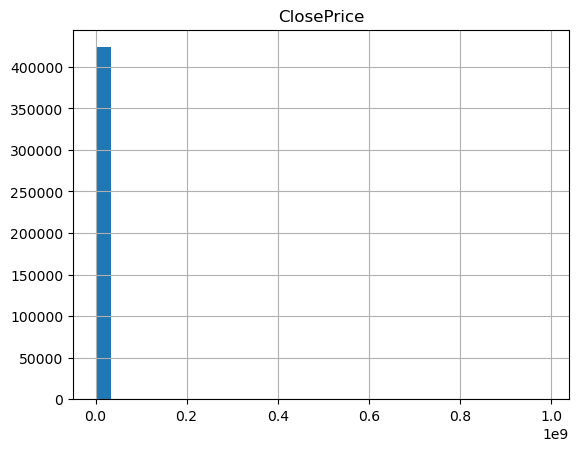

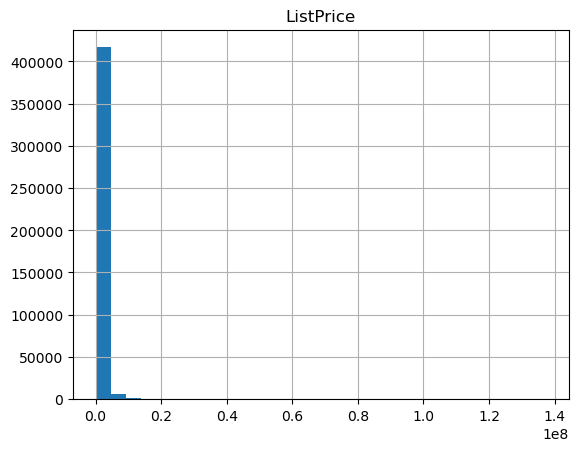

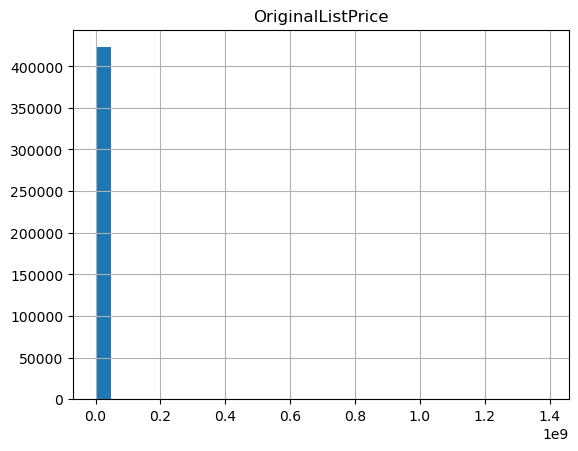

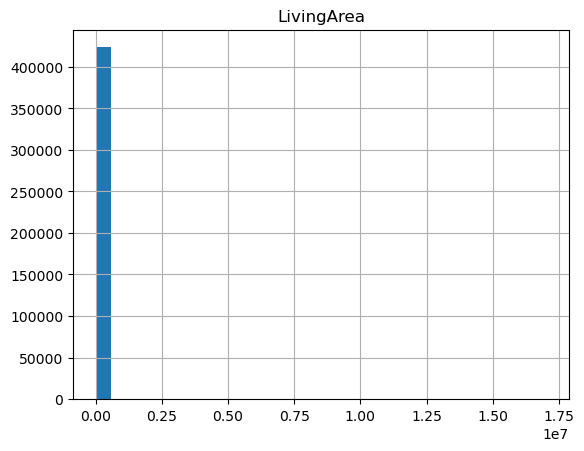

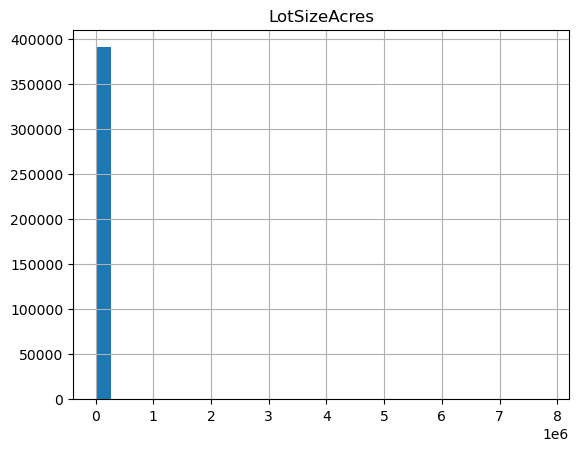

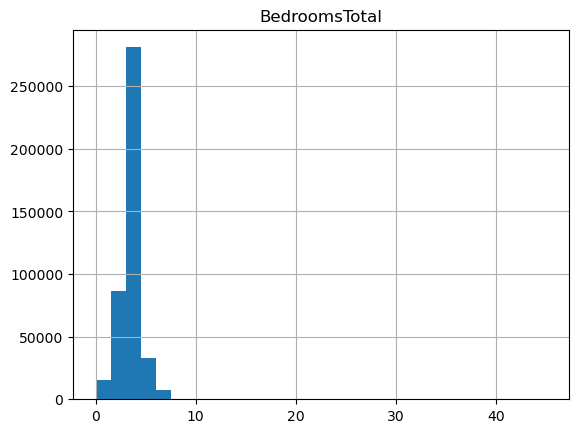

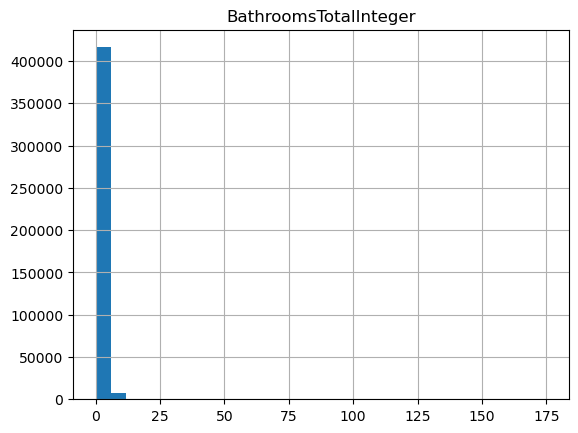

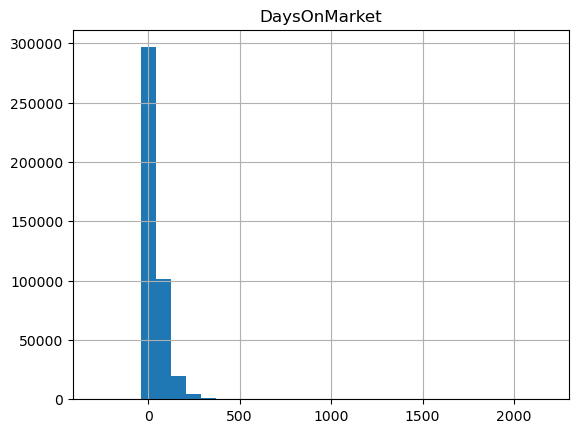

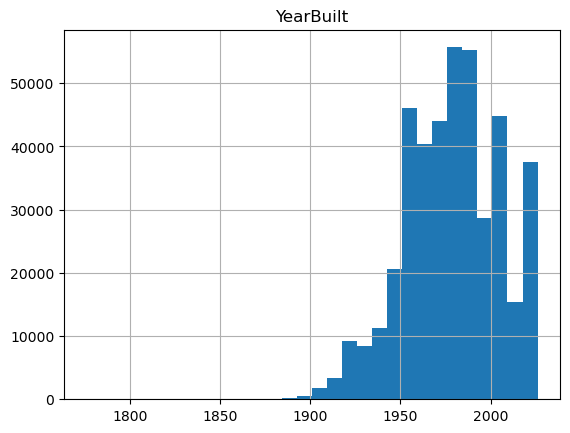

In [16]:
#Historgram numeric distribution for key numeric fields for sold
for column in numeric_cols_sold:
    final_sold[column].hist(bins=30)
    plt.title(column)
    plt.show()

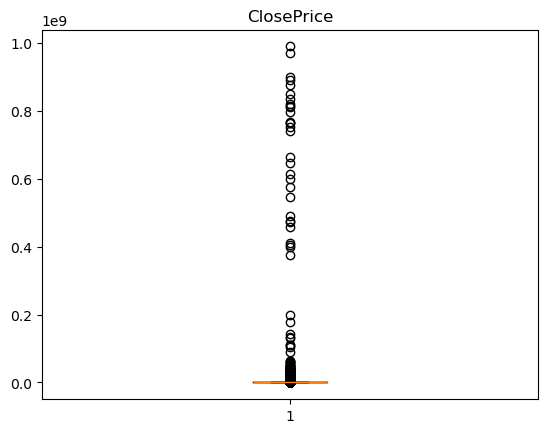

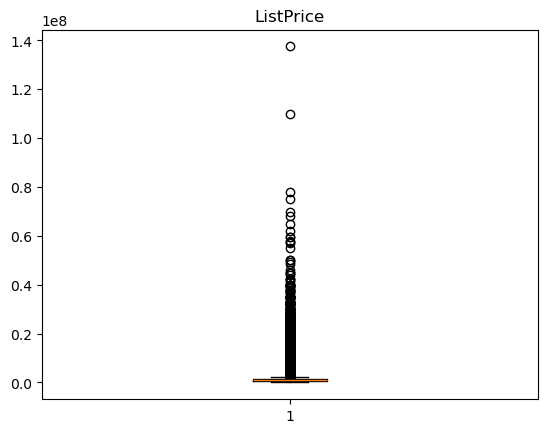

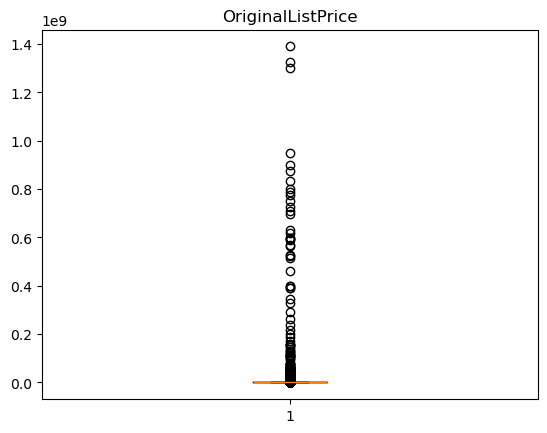

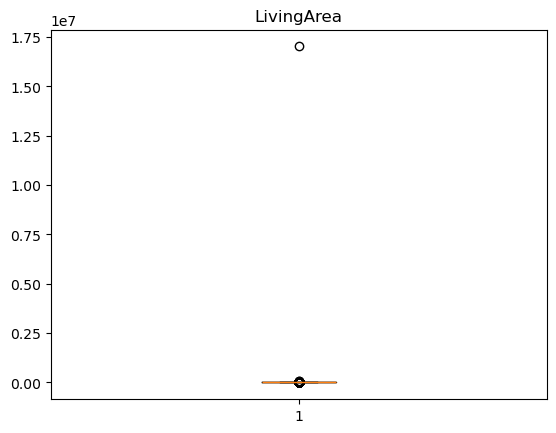

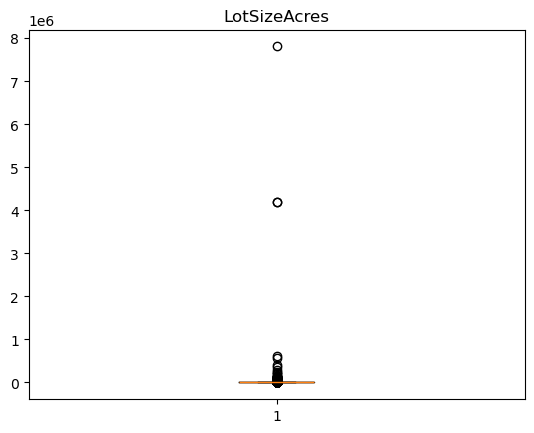

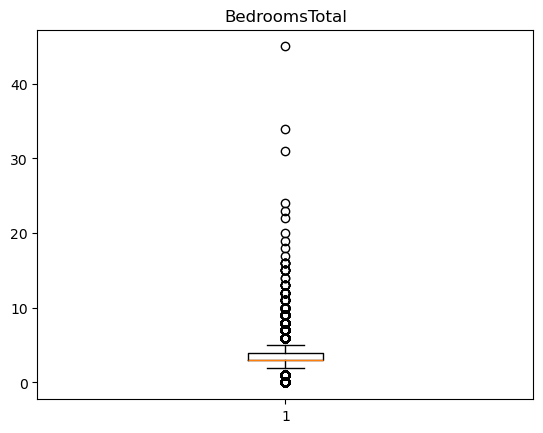

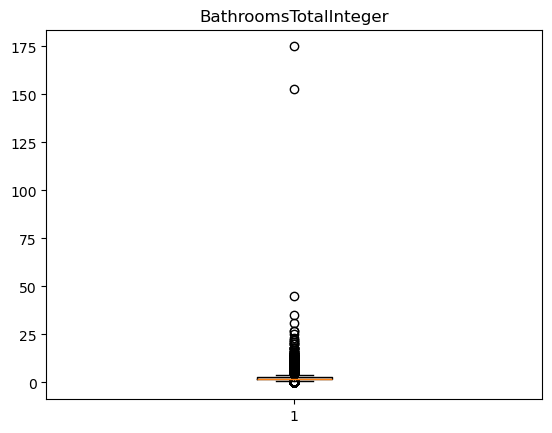

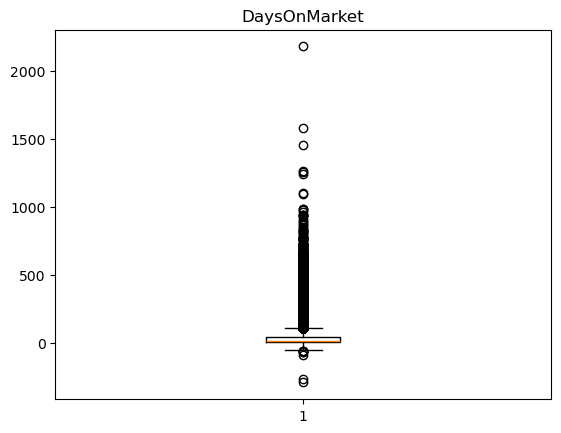

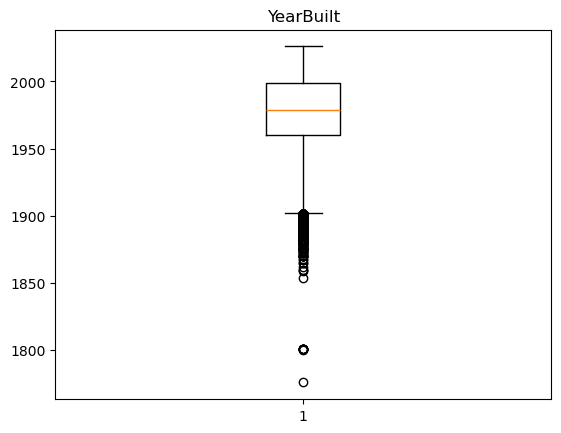

In [17]:
#Boxplot numeric distribution for key numeric fields for sold
for column in numeric_cols_sold:
    plt.boxplot(final_sold[column].dropna())
    plt.title(column)
    plt.show()

## Listings Dataset

### Dataset Understanding

In [18]:
#first five rows of listing dataset
list.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,NaN,2220 Avenue Of The Stars 2704
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,NaN,16 Palisades
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,NaN,2250 Indian Creek Road
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,NaN,317 E. Bayfront


In [19]:
#591,465 rows and 84 columns for listings
list.shape

(591465, 84)

In [20]:
#all the names of the columns in listings
list.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'Cit

In [21]:
#datatypes for all the columns in listings
list.dtypes

OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                   object
CloseDate                        object
ClosePrice                      float64
                                 ...   
BuyerOfficeName.1                object
AssociationFee                  float64
LotSizeSquareFeet               float64
MiddleOrJuniorSchoolDistrict    float64
UnparsedAddress.1                object
Length: 84, dtype: object

In [22]:
#identify property types in list
list["PropertyType"].value_counts()

PropertyType
Residential    591465
Name: count, dtype: int64

In [23]:
#Checking propety type categories in list
list["PropertyType"].unique()

array(['Residential'], dtype=object)

In [24]:
#filter to just residential property types and identify the shape of the new list dataset
list_new = list[list["PropertyType"]=="Residential"]
list_new.shape

(591465, 84)

### Missing Value Analysis

In [25]:
#identify percentage of missing data in the columns of list
list_missing_percent = list_new.isnull().mean()*100
list_missing_percent

OriginalListPrice                 0.142358
ListingKey                        0.000000
ListAgentEmail                    4.307947
CloseDate                        71.475404
ClosePrice                       75.351881
                                   ...    
BuyerOfficeName.1                73.110835
AssociationFee                   24.109288
LotSizeSquareFeet                 8.087883
MiddleOrJuniorSchoolDistrict    100.000000
UnparsedAddress.1                 0.143711
Length: 84, dtype: float64

In [26]:
#identify which columns in list are over 90% missing data
list_missing_percent[list_missing_percent>90].index

Index(['FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount',
       'BuilderName', 'TaxYear', 'BuildingAreaTotal',
       'ElementarySchoolDistrict', 'CoBuyerAgentFirstName',
       'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces',
       'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict'],
      dtype='object')

In [27]:
#drop irrelevants columns that have over 90% missing data in list
drop_list_cols = ['FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount',
       'BuilderName', 'TaxYear', 'BuildingAreaTotal',
       'ElementarySchoolDistrict', 'CoBuyerAgentFirstName',
       'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces',
       'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict']
final_listings = list_new.drop(columns=drop_list_cols)
final_listings.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,177861.0,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,2220 Avenue Of The Stars 2704
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,5300.0,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,16 Palisades
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,9404.0,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,1615 Waverly Road
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,58232.0,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,2250 Indian Creek Road
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,2250.0,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,317 E. Bayfront


### Numeric Distribution

In [28]:
#Percentile summaries for the following columns in list
numeric_cols_list = ["ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea", "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket", "YearBuilt"]
final_listings[numeric_cols_list].describe(percentiles=[0.10,0.25,0.50,0.75,0.90])

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,1.457850e+05,5.914650e+05,5.906230e+05,5.908630e+05,5.429020e+05,591303.000000,591408.000000,591465.000000,590448.000000
mean,1.209678e+06,1.318468e+06,1.402482e+06,1.980143e+03,6.143188e+01,3.226742,2.630208,18.682595,1979.686531
std,4.296045e+06,2.411247e+06,7.313720e+06,2.235101e+04,1.160067e+04,1.188312,3.136176,25.889653,27.026516
min,5.250000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-58.000000,1776.000000
10%,4.300000e+05,4.199000e+05,4.200000e+05,9.630000e+02,6.000000e-02,2.000000,1.000000,1.000000,1947.000000
25%,6.000000e+05,5.805320e+05,5.850000e+05,1.248000e+03,1.200000e-01,2.000000,2.000000,5.000000,1961.000000
50%,8.580000e+05,8.488880e+05,8.490000e+05,1.672000e+03,1.700000e-01,3.000000,2.000000,11.000000,1980.000000
75%,1.352000e+06,1.385000e+06,1.395000e+06,2.302000e+03,3.161750e-01,4.000000,3.000000,22.000000,2001.000000
90%,2.150000e+06,2.350000e+06,2.385000e+06,3.155000e+03,1.359300e+00,5.000000,4.000000,41.000000,2018.000000
max,8.200000e+08,4.000000e+08,1.390000e+09,1.702132e+07,4.187292e+06,94.000000,2208.000000,1063.000000,2028.000000


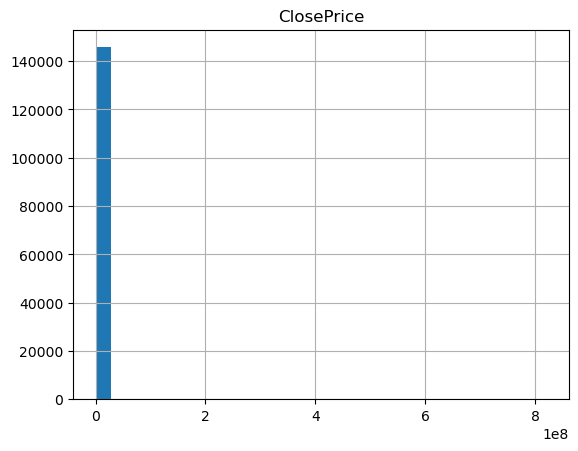

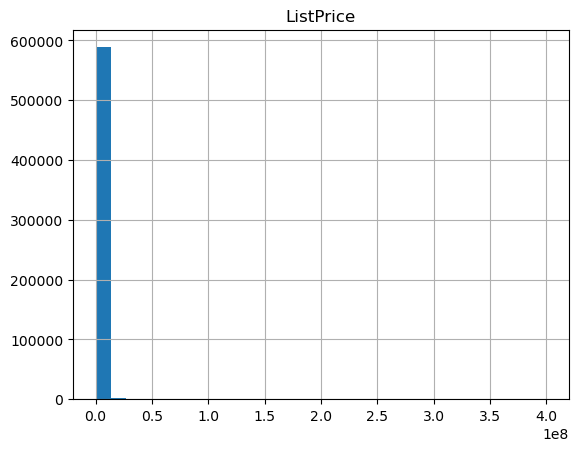

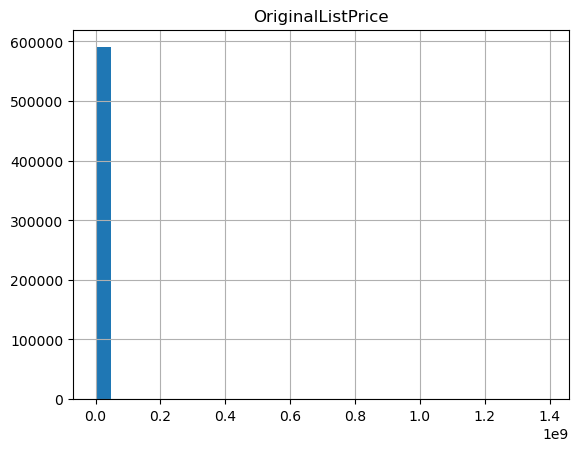

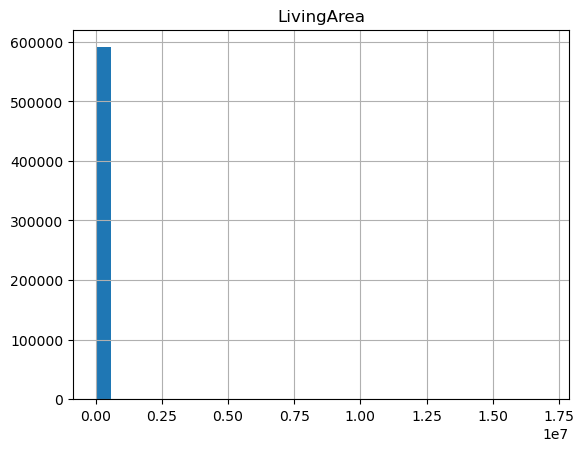

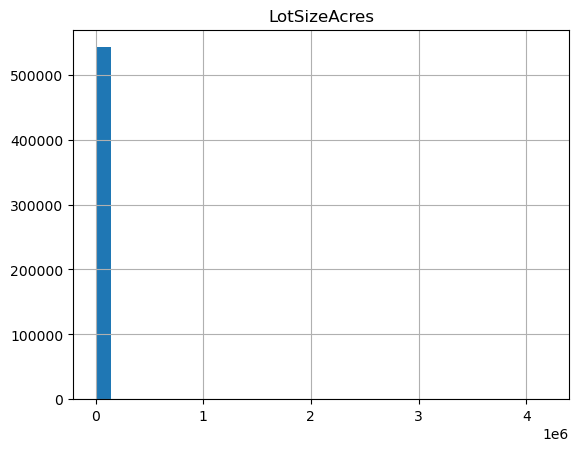

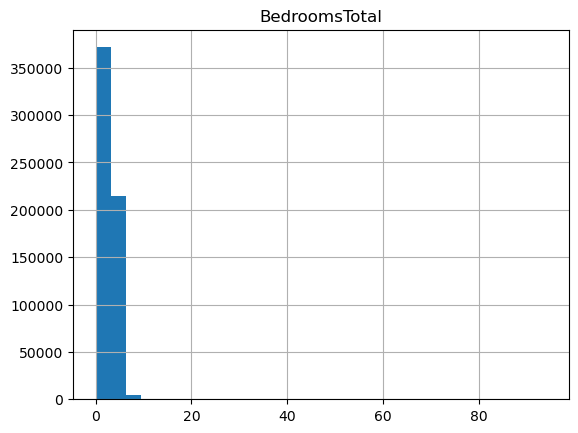

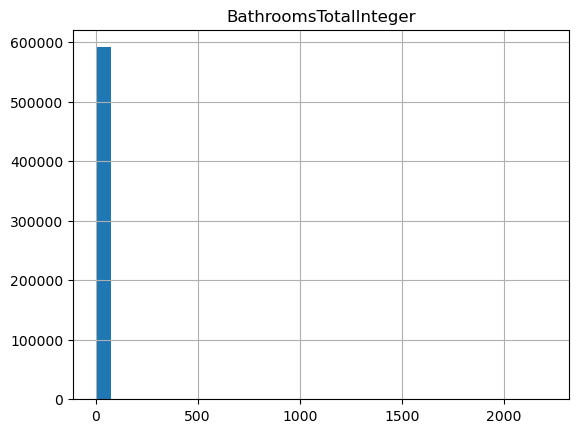

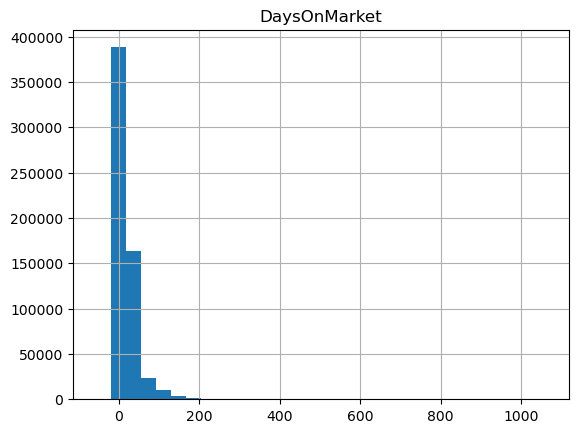

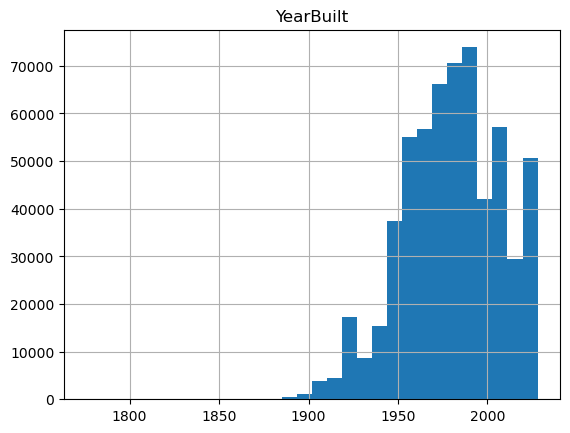

In [29]:
#Historgram numeric distribution for key numeric fields for list
for column in numeric_cols_list:
    final_listings[column].hist(bins=30)
    plt.title(column)
    plt.show()

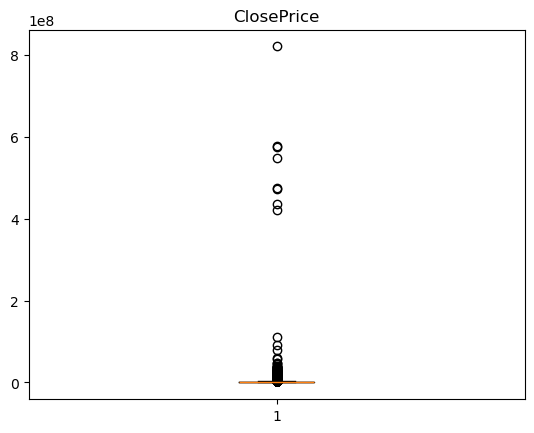

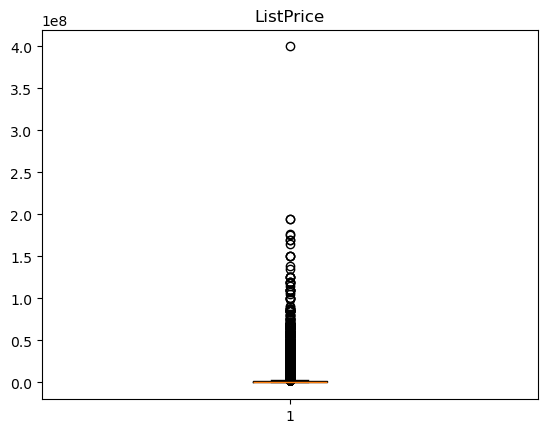

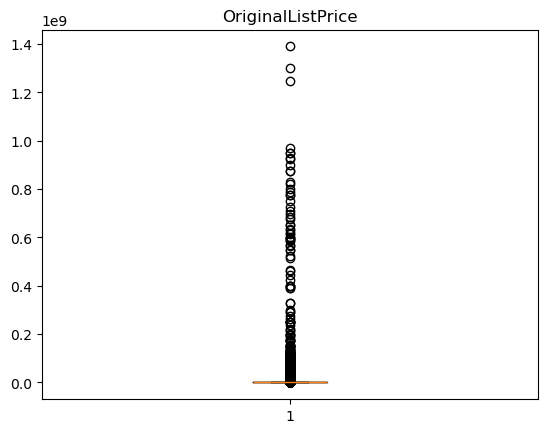

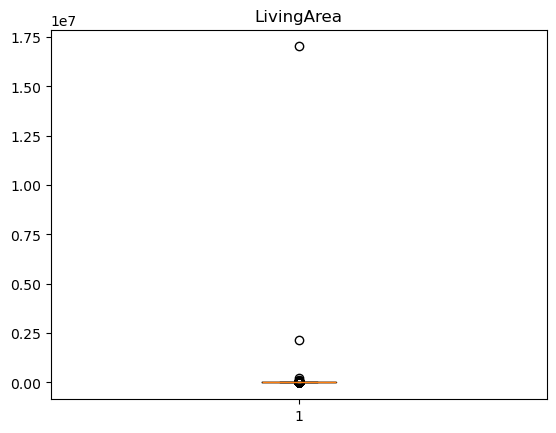

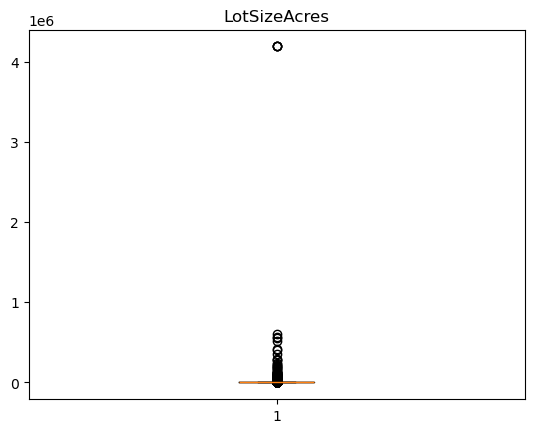

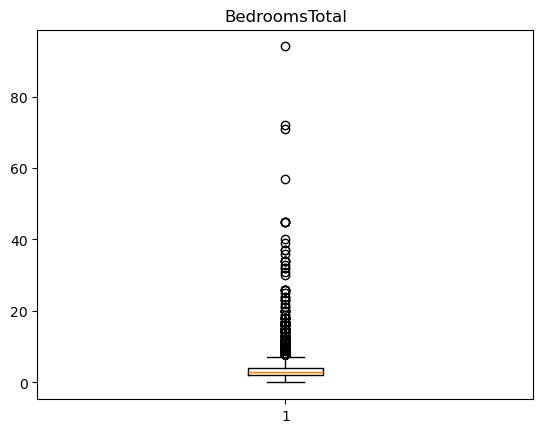

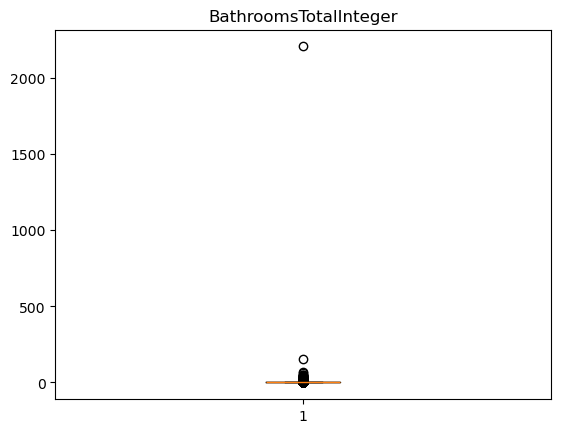

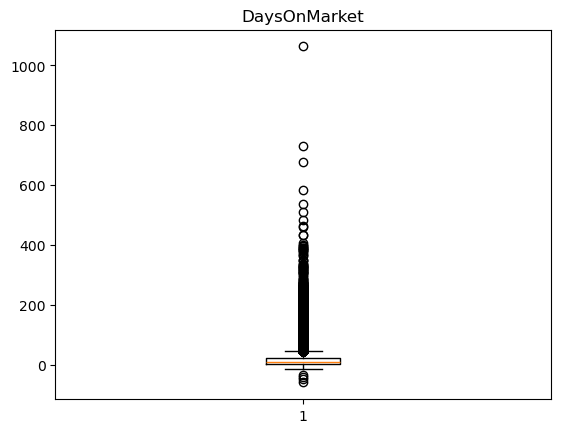

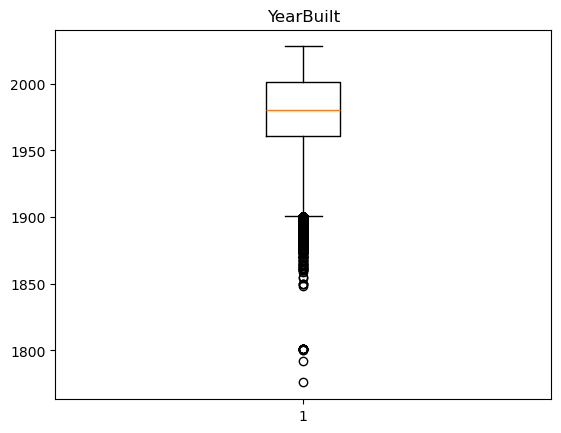

In [30]:
#Boxplot numeric distribution for key numeric fields for listings
for column in numeric_cols_list:
    plt.boxplot(final_listings[column].dropna())
    plt.title(column)
    plt.show()

## Suggested Intern Questions EDA

In [31]:
#Mean and Median of Close Prices
print(sold["ClosePrice"].mean())
print(sold["ClosePrice"].median())

1187414.174724504
820000.0


<Axes: >

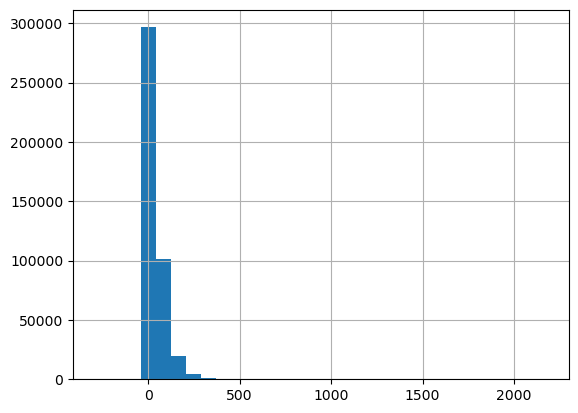

In [32]:
#Days on Market Distribution
sold["DaysOnMarket"].hist(bins=30)

In [33]:
#Sold above or below list price
above = sold["ClosePrice"] > sold["ListPrice"]
above.value_counts(normalize=True)*100

False    60.264807
True     39.735193
Name: proportion, dtype: float64

In [34]:
#Date Consistency
sold[sold["CloseDate"]<sold["ListingContractDate"]]

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation
22,SanDiego,SanDiego,NaN,False,NaN,NaN,False,2195000.0,1059827487,RE@juliefeld.com,...,3.0,NaN,92067,1400.0,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN
83,SanDiego,SanDiego,NaN,False,NaN,NaN,False,2705000.0,1059357897,lindsay@thedunlapteam.com,...,2.0,NaN,92014,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN
711,SanDiego,SanDiego,NaN,True,NaN,NaN,False,1600000.0,1054052014,joseph@arendsengroup.com,...,2.0,NaN,92054,695.0,13567.0,NaN,CRMLS,CRMLS_SAND,NaN,NaN
24279,NaN,NaN,"Carpet,Laminate",True,NaN,NaN,False,1075000.0,1065738283,JulieBradenHomes@gmail.com,...,3.0,NaN,91320,135.0,2615.0,NaN,NaN,NaN,Item1,2.5
24399,NaN,NaN,NaN,True,NaN,NaN,False,1595000.0,1063548623,jamie@gregcummings.com,...,0.0,NaN,92110,NaN,NaN,NaN,NaN,NaN,Item1,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391188,SanDiego,SanDiego,NaN,False,NaN,NaN,False,900000.0,1157489159,ryan.main@compass.com,...,2.0,NaN,92104,NaN,4548.0,NaN,CRMLS,CRMLS_SAND,NaN,NaN
407466,Conejo,Conejo,Carpet,False,NaN,NaN,False,575000.0,1174261376,NaN,...,1.0,NaN,93063,NaN,3920.0,NaN,CRMLS,CRMLS_VCR,NaN,NaN
407475,NaN,Mlslistings,NaN,False,NaN,NaN,NaN,3850000.0,1173168937,NaN,...,4.0,Other,95132,NaN,24829.2,NaN,CRMLS,CRMLS_MLSL,NaN,NaN
407699,SanDiego,SanDiego,NaN,False,NaN,NaN,False,3000000.0,1168402079,NaN,...,2.0,NaN,92037,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN


In [35]:
#Highest Median Price by County
sold.groupby("CountyOrParish")["ClosePrice"].median().sort_values(ascending=False)

CountyOrParish
Del Norte          2485000.0
San Mateo          1700000.0
Santa Clara        1600000.0
Marin              1200000.0
San Francisco      1199900.0
                     ...    
Imperial            305500.0
Modoc               282000.0
Sierra              255000.0
Foreign Country     225000.0
Lassen              135000.0
Name: ClosePrice, Length: 63, dtype: float64

## Saving updated datasets as CSV files

In [36]:
final_listings.to_csv("ResidentialListingsFINAL.csv",index=False)
final_sold.to_csv("ResidentialSoldFINAL.csv",index=False)